In [1]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plot, cm
import numpy as np

In [2]:
# declaring variables

domain = 2
nx = ny = 101
nt = 80
c = 1
dx = domain / (nx - 1)
dy = domain / (ny - 1)
sigma = 0.2             # recall sigma = dt/dx
dt = sigma * dx
print(dt)
print('t = ', (nt * dt))

x = np.linspace(0, domain, nx)
y = np.linspace(0, domain, ny)

u = np.ones((nx, ny))
v = np.ones((nx, ny))

#initial conditions

u[int(0.5 / dx):int((1 / dx) + 1),int(0.5 / dy):int((1 / dy) + 1)] = 2
v[int(0.5 / dx):int((1 / dx) + 1),int(0.5 / dy):int((1 / dy) + 1)] = 2

0.004
t =  0.32


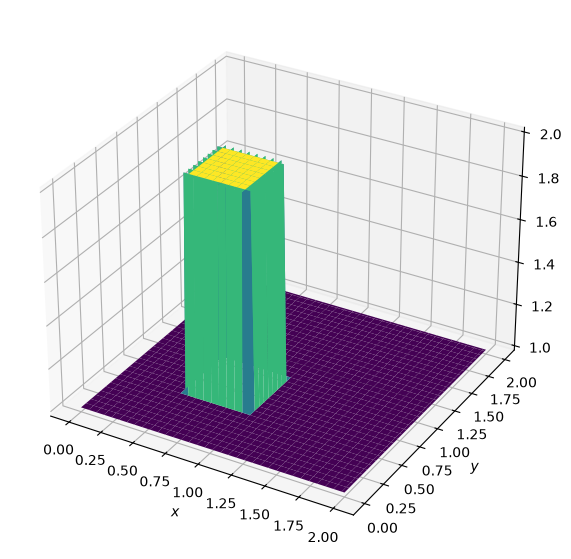

In [3]:
fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.

X, Y = np.meshgrid(x,y)

surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');

In [4]:
# discretized equations and looping

for n in range(nt):
    un = u.copy()
    vn = v.copy()

    u[1:,1:] =( un[1:,1:] - un[1:,1:] * (dt/dx) * (un[1:,1:] - un[:-1,1:])
             - vn[1:,1:] * (dt/dy) * (un[1:,1:] - un[1:,:-1]) )
    v[1:,1:] =( vn[1:,1:] - un[1:,1:] * (dt/dx) * (vn[1:,1:] - vn[:-1,1:])
             - vn[1:,1:] * (dt/dy) * (vn[1:,1:] - vn[1:,:-1]) )
    
    # Boundary Conditions where u = v = 1
    # at lines whose equations are (x = 0, x = 2, y = 0, y = 0)
    u[0,:] = v[0,:] = 1
    u[-1,:] = v[-1,:] = 1
    u[:,0] = v[:,0] = 1
    u[:,-1] = v[:,-1] = 1

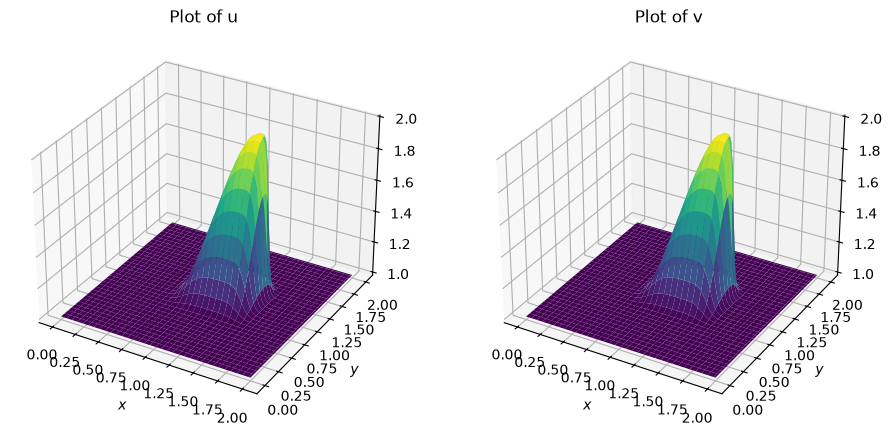

In [5]:
fig = plot.figure(figsize = (11,7), dpi=100)  # Adjust the size to accommodate two plots

ax1 = fig.add_subplot(121, projection='3d')  # The '121' means a grid of 1 row and 2 columns, and this is the first plot
X, Y = np.meshgrid(x,y)
surf1 = ax1.plot_surface(X,Y,u,cmap=cm.viridis)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_title('Plot of u')

ax2 = fig.add_subplot(122, projection='3d')  # The '122' means a grid of 1 row and 2 columns, and this is the second plot
surf2 = ax2.plot_surface(X,Y,v,cmap=cm.viridis)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_title('Plot of v')

plot.show()